#### Install and Import Libraries

In [12]:
# First, extract the zip file (run this only once)
import zipfile
import os

# Auto-detect: finds the zip file in the SAME folder as this notebook
notebook_folder = os.getcwd()          # gets the folder where this notebook is saved
zip_path        = os.path.join(notebook_folder, 'archive.zip')
extract_path    = os.path.join(notebook_folder, 'archive_extracted')

# Check zip exists before trying
if not os.path.exists(zip_path):
    print(' archive.zip not found in:', notebook_folder)
    print('   Make sure archive.zip is in the SAME folder as this notebook!')
else:
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(extract_path)
    print(' Zip extracted successfully!')
    print('   Extracted to:', extract_path)

 Zip extracted successfully!
   Extracted to: C:\Users\ARCHANA\computervision_cw\archive_extracted


In [14]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

print('All libraries imported!')

All libraries imported!


#### Set dataset path

In [17]:
# Tell Python where our dataset is located
# Uses the same folder as the notebook automatically
notebook_folder = os.getcwd()

TRAIN_PATH = os.path.join(notebook_folder, 'archive_extracted', 'Training')
TEST_PATH  = os.path.join(notebook_folder, 'archive_extracted', 'Testing')

# Check if the folders actually exist
print('Training folder exists:', os.path.exists(TRAIN_PATH))
print('Testing  folder exists:', os.path.exists(TEST_PATH))


Training folder exists: True
Testing  folder exists: True


#### What classes (Categories) Do we have?

In [22]:
# Get the list of class folders inside Training
classes = sorted(os.listdir(TRAIN_PATH))

print('Number of classes:', len(classes))
print('Class names:', classes)

Number of classes: 4
Class names: ['glioma', 'meningioma', 'notumor', 'pituitary']


#### How many Images in Each Class?

In [25]:
print(f'{"Class":<15} {"Train Images":>15} {"Test Images":>13}')
print('-' * 45)

train_counts = {}
test_counts  = {}

for cls in classes:
    # Count files in each class folder
    train_imgs = os.listdir(os.path.join(TRAIN_PATH, cls))
    test_imgs  = os.listdir(os.path.join(TEST_PATH,  cls))

    train_counts[cls] = len(train_imgs)
    test_counts[cls]  = len(test_imgs)

    print(f'{cls:<15} {len(train_imgs):>15} {len(test_imgs):>13}')

print('-' * 45)
print(f'{"TOTAL":<15} {sum(train_counts.values()):>15} {sum(test_counts.values()):>13}')


Class              Train Images   Test Images
---------------------------------------------
glioma                     1400           400
meningioma                 1400           400
notumor                    1400           400
pituitary                  1400           400
---------------------------------------------
TOTAL                      5600          1600


#### Bar Chart: Images Per Class

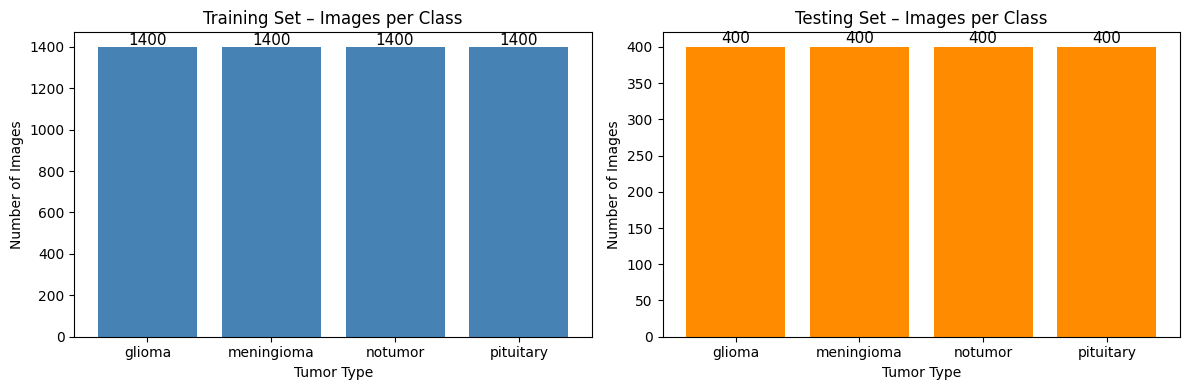

Chart saved as class_distribution.png


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Training bar chart ---
axes[0].bar(train_counts.keys(), train_counts.values(), color='steelblue')
axes[0].set_title('Training Set – Images per Class', fontsize=12)
axes[0].set_xlabel('Tumor Type')
axes[0].set_ylabel('Number of Images')
# Add number on top of each bar
for i, (cls, count) in enumerate(train_counts.items()):
    axes[0].text(i, count + 10, str(count), ha='center', fontsize=11)

# --- Testing bar chart ---
axes[1].bar(test_counts.keys(), test_counts.values(), color='darkorange')
axes[1].set_title('Testing Set – Images per Class', fontsize=12)
axes[1].set_xlabel('Tumor Type')
axes[1].set_ylabel('Number of Images')
for i, (cls, count) in enumerate(test_counts.items()):
    axes[1].text(i, count + 5, str(count), ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('class_distribution.png')
plt.show()
print('Chart saved as class_distribution.png')


#### Show One Sample Image from Each Class

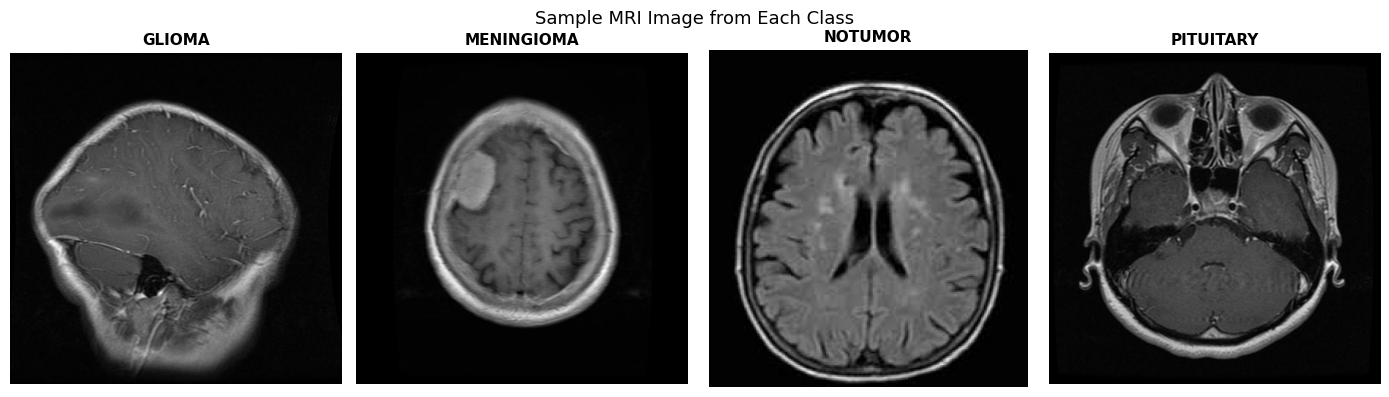

Sample images saved as sample_images.png


In [31]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))

for ax, cls in zip(axes, classes):
    cls_folder = os.path.join(TRAIN_PATH, cls)

    # Pick a random image from this class
    img_name   = random.choice(os.listdir(cls_folder))
    img_path   = os.path.join(cls_folder, img_name)

    # Open and show the image
    img = Image.open(img_path).convert('RGB')
    ax.imshow(img)
    ax.set_title(cls.upper(), fontsize=11, fontweight='bold')
    ax.axis('off')   # hide the x/y axis numbers

plt.suptitle('Sample MRI Image from Each Class', fontsize=13)
plt.tight_layout()
plt.savefig('sample_images.png')
plt.show()
print('Sample images saved as sample_images.png')

#### Check Image Size(Width and Height)

In [36]:
widths  = []
heights = []

# Check 20 random images from each class
for cls in classes:
    cls_folder = os.path.join(TRAIN_PATH, cls)
    images     = os.listdir(cls_folder)[:20]   # only first 20 to save time

    for img_name in images:
        img_path = os.path.join(cls_folder, img_name)
        img      = Image.open(img_path)
        w, h     = img.size          # width, height in pixels
        widths.append(w)
        heights.append(h)

print(f'Width  → Min: {min(widths)}  Max: {max(widths)}  Average: {int(np.mean(widths))}')
print(f'Height → Min: {min(heights)}  Max: {max(heights)}  Average: {int(np.mean(heights))}')
print(f'\nTotal images checked: {len(widths)}')

Width  → Min: 192  Max: 630  Average: 463
Height → Min: 183  Max: 686  Average: 464

Total images checked: 80


#### Check Image Color Mode (RGB or Grayscale?)

In [41]:
color_modes = {}   # dictionary to count how many images are RGB, L, etc.

for cls in classes:
    cls_folder = os.path.join(TRAIN_PATH, cls)
    images     = os.listdir(cls_folder)[:20]

    for img_name in images:
        img_path = os.path.join(cls_folder, img_name)
        img      = Image.open(img_path)
        mode     = img.mode   # 'RGB' = colour,  'L' = grayscale

        if mode not in color_modes:
            color_modes[mode] = 0
        color_modes[mode] += 1

print('Color modes found in the dataset:')
for mode, count in color_modes.items():
    print(f'  {mode} → {count} images')

Color modes found in the dataset:
  L → 31 images
  RGB → 49 images


#### Check for Corrupt/Broken Images

In [47]:
corrupt_images = []   # list to store any broken image paths

for cls in classes:
    cls_folder = os.path.join(TRAIN_PATH, cls)

    for img_name in os.listdir(cls_folder):
        img_path = os.path.join(cls_folder, img_name)
        try:
            img = Image.open(img_path)
            img.verify()   # checks if the image file is valid
        except Exception:
            corrupt_images.append(img_path)

if len(corrupt_images) == 0:
    print(' No corrupt images found! All images are healthy.')
else:
    print(f'  Found {len(corrupt_images)} corrupt images:')
    for p in corrupt_images:
        print(' ', p)


 No corrupt images found! All images are healthy.


#### Final Summary Checklist

In [50]:
print('=' * 50)
print('       DATASET REQUIREMENTS CHECKLIST')
print('=' * 50)

checks = [
    ('Training folder exists',          os.path.exists(TRAIN_PATH)),
    ('Testing folder exists',           os.path.exists(TEST_PATH)),
    ('Has 4 classes',                   len(classes) == 4),
    ('Train images >= 100 per class',   all(v >= 100 for v in train_counts.values())),
    ('Test  images >= 50  per class',   all(v >= 50  for v in test_counts.values())),
    ('No corrupt images',               len(corrupt_images) == 0),
    ('Images are readable (RGB/L)',     len(color_modes) > 0),
]

all_good = True
for description, result in checks:
    icon = 'yes' if result else 'No'
    print(f'  {icon}  {description}')
    if not result:
        all_good = False

print('=' * 50)
if all_good:
    print('   Dataset is READY for training!')
else:
    print('   Some issues found. Please review above.')
print('=' * 50)


       DATASET REQUIREMENTS CHECKLIST
  yes  Training folder exists
  yes  Testing folder exists
  yes  Has 4 classes
  yes  Train images >= 100 per class
  yes  Test  images >= 50  per class
  yes  No corrupt images
  yes  Images are readable (RGB/L)
   Dataset is READY for training!
